In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr


current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

enriched_directory = (
    project_root
    / "data"
    / "enriched"
)

validated_directory = (
    project_root
    / "data"
    / "validated"
)

sql_output_directory = (
    project_root
    / "outputs"
    / "tables"
    / "sql_analysis"
)

charts_directory = (
    project_root
    / "outputs"
    / "charts"
    / "eda"
)

tables_directory = (
    project_root
    / "outputs"
    / "tables"
    / "eda"
)

charts_directory.mkdir(
    parents=True,
    exist_ok=True
)

tables_directory.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:", project_root)
print("EDA chart folder:", charts_directory)

Project root: e:\PROJECTS (selfstudy)\expernetic-airbnb-data-engineering
EDA chart folder: e:\PROJECTS (selfstudy)\expernetic-airbnb-data-engineering\outputs\charts\eda


In [4]:
listings = pd.read_parquet(
    enriched_directory
    / "listing_enriched.parquet"
)

calendar = pd.read_parquet(
    validated_directory
    / "calendar_valid.parquet"
)

reviews = pd.read_parquet(
    validated_directory
    / "reviews_detailed_valid.parquet"
)

neighbourhood_summary = pd.read_parquet(
    enriched_directory
    / "neighbourhood_summary.parquet"
)

monthly_review_activity = pd.read_csv(
    sql_output_directory
    / "monthly_review_activity.csv"
)

monthly_availability = pd.read_csv(
    sql_output_directory
    / "monthly_availability.csv"
)

host_market_concentration = pd.read_csv(
    sql_output_directory
    / "host_market_concentration.csv"
)

print("Listings:", listings.shape)
print("Calendar:", calendar.shape)
print("Reviews:", reviews.shape)
print("Neighbourhood summary:", neighbourhood_summary.shape)

Listings: (3247, 123)
Calendar: (1185155, 7)
Reviews: (41265, 9)
Neighbourhood summary: (42, 10)


In [5]:
def save_chart(
    file_name: str
) -> None:
    output_path = (
        charts_directory
        / file_name
    )

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print("Saved:", output_path)


def save_table(
    dataframe: pd.DataFrame,
    file_name: str
) -> None:
    output_path = (
        tables_directory
        / file_name
    )

    dataframe.to_csv(
        output_path,
        index=False
    )

    print("Saved:", output_path)

Market Overview

In [6]:
price_values = pd.to_numeric(
    listings["price"],
    errors="coerce"
).dropna()

market_overview = pd.DataFrame([
    {
        "total_listings": listings["id"].nunique(),
        "total_hosts": listings["host_id"].nunique(),
        "total_neighbourhoods": (
            listings[
                "neighbourhood_cleansed"
            ].nunique()
        ),
        "listings_with_price": int(
            listings["price"].notna().sum()
        ),
        "missing_price_count": int(
            listings["price"].isna().sum()
        ),
        "median_price": round(
            price_values.median(),
            2
        ),
        "average_price": round(
            price_values.mean(),
            2
        ),
        "price_25th_percentile": round(
            price_values.quantile(0.25),
            2
        ),
        "price_75th_percentile": round(
            price_values.quantile(0.75),
            2
        ),
        "price_95th_percentile": round(
            price_values.quantile(0.95),
            2
        ),
        "maximum_price": round(
            price_values.max(),
            2
        ),
        "listings_with_reviews": int(
            (
                listings[
                    "detailed_review_count"
                ] > 0
            ).sum()
        )
    }
])

display(market_overview)

save_table(
    market_overview,
    "market_overview.csv"
)

,total_listings,total_hosts,total_neighbourhoods,listings_with_price,missing_price_count,median_price,average_price,price_25th_percentile,price_75th_percentile,price_95th_percentile,maximum_price,listings_with_reviews
0,3247,762,42,2742,505,130.05,204.24,45.48,250.0,578.23,13000.0,1839


Saved: e:\PROJECTS (selfstudy)\expernetic-airbnb-data-engineering\outputs\tables\eda\market_overview.csv


## Business interpretation

This table provides the main size, price, and review-coverage measures for
the Singapore Airbnb dataset. Median price should be used as the main market
benchmark because a small number of expensive listings may increase the
average price.

Listing price distribution

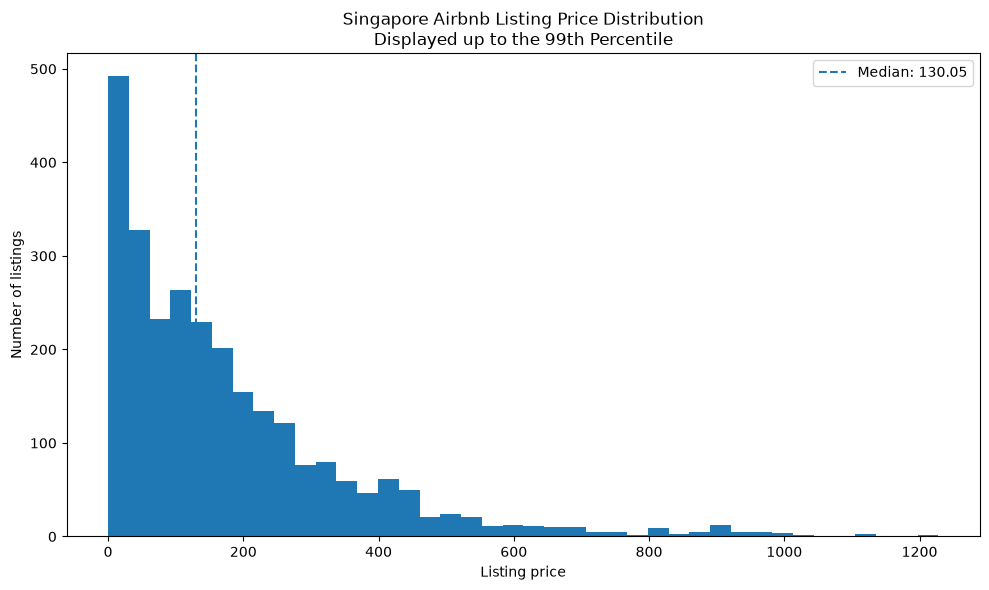

Saved: e:\PROJECTS (selfstudy)\expernetic-airbnb-data-engineering\outputs\charts\eda\01_price_distribution.png


In [7]:
price_99th_percentile = (
    price_values.quantile(0.99)
)

price_for_chart = price_values[
    price_values
    <= price_99th_percentile
]

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    price_for_chart,
    bins=40
)

plt.axvline(
    price_values.median(),
    linestyle="--",
    label=(
        f"Median: "
        f"{price_values.median():,.2f}"
    )
)

plt.title(
    "Singapore Airbnb Listing Price Distribution\n"
    "Displayed up to the 99th Percentile"
)

plt.xlabel("Listing price")
plt.ylabel("Number of listings")
plt.legend()

save_chart(
    "01_price_distribution.png"
)

## Business interpretation

The distribution should be interpreted using the median rather than only the
average because premium listings create a long upper price tail. Hosts should
compare prices with similar room types and neighbourhoods instead of using a
single market-wide average.

Room-type pricing

In [8]:
room_type_summary = (
    listings
    .groupby(
        "room_type",
        dropna=False
    )
    .agg(
        listing_count=(
            "id",
            "nunique"
        ),
        listings_with_price=(
            "price",
            "count"
        ),
        median_price=(
            "price",
            "median"
        ),
        average_price=(
            "price",
            "mean"
        ),
        average_rating=(
            "review_scores_rating",
            "mean"
        ),
        average_occupancy_proxy=(
            "estimated_occupancy_proxy",
            "mean"
        )
    )
    .reset_index()
)

room_type_summary[
    "listing_share_percentage"
] = (
    room_type_summary[
        "listing_count"
    ]
    / room_type_summary[
        "listing_count"
    ].sum()
    * 100
)

room_type_summary[
    "average_occupancy_proxy_percentage"
] = (
    room_type_summary[
        "average_occupancy_proxy"
    ] * 100
)

numeric_columns = [
    "median_price",
    "average_price",
    "average_rating",
    "listing_share_percentage",
    "average_occupancy_proxy_percentage"
]

room_type_summary[
    numeric_columns
] = room_type_summary[
    numeric_columns
].round(2)

room_type_summary = (
    room_type_summary
    .sort_values(
        "median_price",
        ascending=False
    )
)

display(room_type_summary)

save_table(
    room_type_summary,
    "room_type_summary.csv"
)

,room_type,listing_count,listings_with_price,median_price,average_price,average_rating,average_occupancy_proxy,listing_share_percentage,average_occupancy_proxy_percentage
0,Entire home/apt,1226,1092,214.11,312.56,4.66,0.181121,37.76,18.11
1,Hotel room,83,74,117.2,165.55,4.39,0.197788,2.56,19.78
2,Private room,1870,1509,93.87,134.12,4.49,0.259243,57.59,25.92
3,Shared room,68,67,48.0,60.77,4.48,0.189444,2.09,18.94


Saved: e:\PROJECTS (selfstudy)\expernetic-airbnb-data-engineering\outputs\tables\eda\room_type_summary.csv


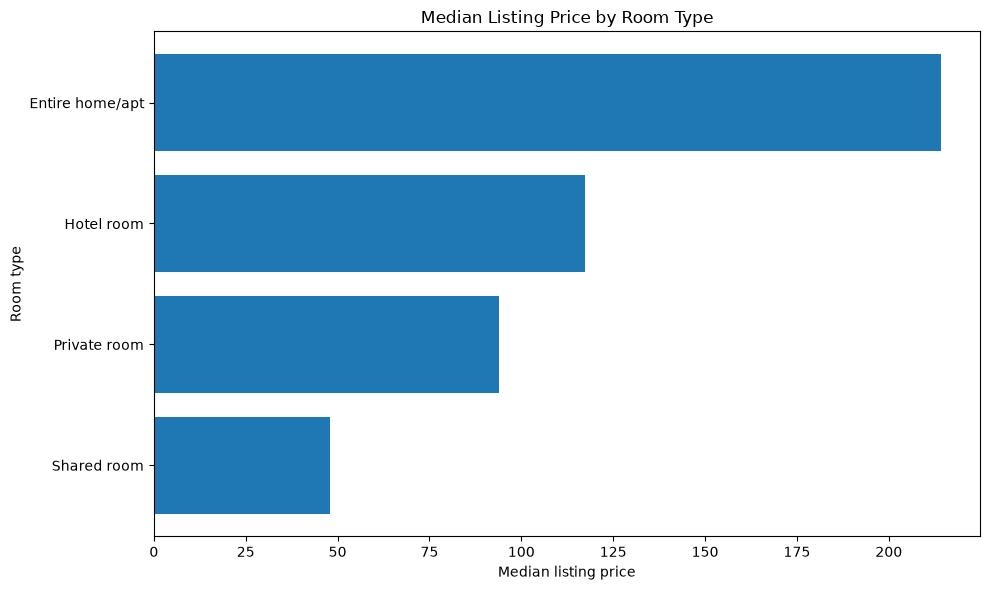

Saved: e:\PROJECTS (selfstudy)\expernetic-airbnb-data-engineering\outputs\charts\eda\02_median_price_by_room_type.png


In [9]:
room_type_plot = (
    room_type_summary
    .dropna(
        subset=["median_price"]
    )
    .sort_values(
        "median_price",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    room_type_plot["room_type"],
    room_type_plot["median_price"]
)

plt.title(
    "Median Listing Price by Room Type"
)

plt.xlabel("Median listing price")
plt.ylabel("Room type")

save_chart(
    "02_median_price_by_room_type.png"
)

## Business interpretation

Room type is an important pricing factor because guests receive different
levels of privacy, space, and capacity. The highest-priced room type should
not be compared directly with lower-priced categories when setting a listing
price.

Neighbourhood pricing

In [10]:
neighbourhood_analysis = (
    listings
    .groupby(
        "neighbourhood_cleansed",
        dropna=False
    )
    .agg(
        listing_count=(
            "id",
            "nunique"
        ),
        listings_with_price=(
            "price",
            "count"
        ),
        unique_host_count=(
            "host_id",
            "nunique"
        ),
        median_price=(
            "price",
            "median"
        ),
        average_price=(
            "price",
            "mean"
        ),
        average_rating=(
            "review_scores_rating",
            "mean"
        ),
        average_occupancy_proxy=(
            "estimated_occupancy_proxy",
            "mean"
        )
    )
    .reset_index()
)

neighbourhood_analysis[
    "average_occupancy_proxy_percentage"
] = (
    neighbourhood_analysis[
        "average_occupancy_proxy"
    ] * 100
)

neighbourhood_analysis = (
    neighbourhood_analysis[
        neighbourhood_analysis[
            "listing_count"
        ] >= 10
    ]
    .copy()
)

neighbourhood_analysis[
    [
        "median_price",
        "average_price",
        "average_rating",
        "average_occupancy_proxy_percentage"
    ]
] = neighbourhood_analysis[
    [
        "median_price",
        "average_price",
        "average_rating",
        "average_occupancy_proxy_percentage"
    ]
].round(2)

display(
    neighbourhood_analysis
    .sort_values(
        "median_price",
        ascending=False
    )
    .head(15)
)

save_table(
    neighbourhood_analysis,
    "neighbourhood_analysis.csv"
)

,neighbourhood_cleansed,listing_count,listings_with_price,unique_host_count,median_price,average_price,average_rating,average_occupancy_proxy,average_occupancy_proxy_percentage
22,Orchard,86,77,18,422.0,456.0,4.8,0.213953,21.40
33,Southern Islands,21,19,9,421.0,639.95,4.81,0.215525,21.55
19,Museum,18,17,12,350.5,383.22,4.33,0.157230,15.72
27,River Valley,404,395,35,230.37,273.78,4.48,0.141360,14.14
36,Tanglin,40,34,18,214.6,294.18,4.72,0.170274,17.03
21,Novena,197,169,44,209.35,200.58,4.7,0.237869,23.79
32,Singapore River,145,138,25,184.88,270.47,4.61,0.198148,19.81
13,Hougang,44,34,25,162.4,263.24,4.69,0.282877,28.29
28,Rochor,283,253,55,155.0,326.65,4.43,0.237969,23.80
26,Queenstown,162,139,35,153.89,195.48,4.49,0.310316,31.03


Saved: e:\PROJECTS (selfstudy)\expernetic-airbnb-data-engineering\outputs\tables\eda\neighbourhood_analysis.csv


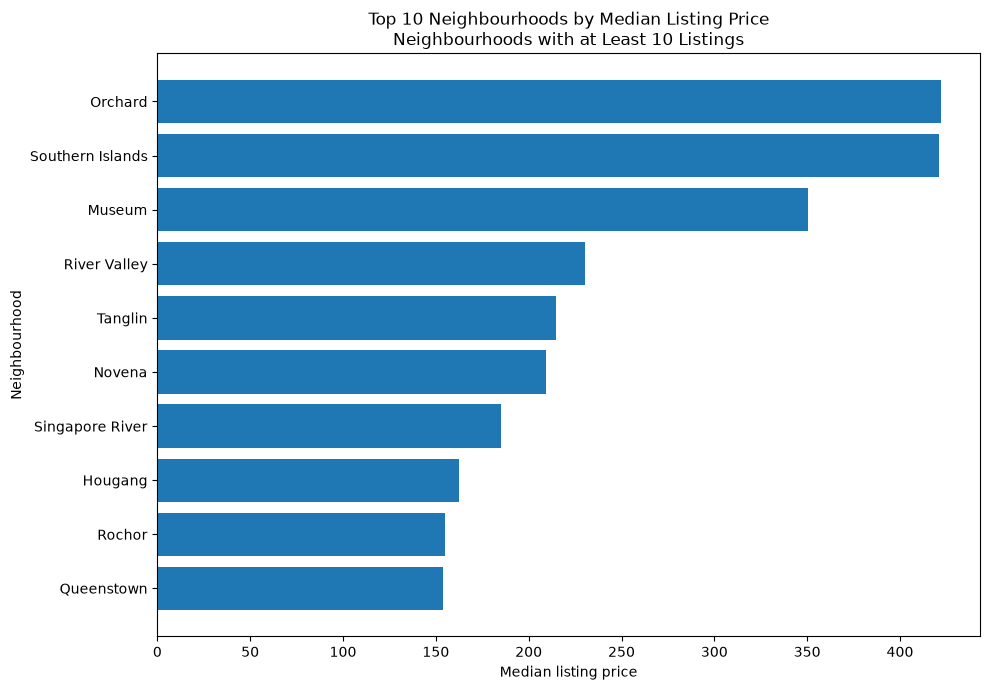

Saved: e:\PROJECTS (selfstudy)\expernetic-airbnb-data-engineering\outputs\charts\eda\03_top_neighbourhoods_by_median_price.png


In [11]:
top_price_neighbourhoods = (
    neighbourhood_analysis
    .dropna(
        subset=["median_price"]
    )
    .sort_values(
        "median_price",
        ascending=False
    )
    .head(10)
    .sort_values(
        "median_price",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_price_neighbourhoods[
        "neighbourhood_cleansed"
    ],
    top_price_neighbourhoods[
        "median_price"
    ]
)

plt.title(
    "Top 10 Neighbourhoods by Median Listing Price\n"
    "Neighbourhoods with at Least 10 Listings"
)

plt.xlabel("Median listing price")
plt.ylabel("Neighbourhood")

save_chart(
    "03_top_neighbourhoods_by_median_price.png"
)

## Business interpretation

Neighbourhood-level pricing provides a more useful benchmark than the overall
market average. However, a high median price does not prove that a
neighbourhood is more profitable because listing size, room type, demand,
and operating costs may also differ.

Host portfolio structure

In [12]:
host_segment_summary = (
    listings
    .groupby(
        "host_segment",
        dropna=False
    )
    .agg(
        listing_count=(
            "id",
            "nunique"
        ),
        unique_host_count=(
            "host_id",
            "nunique"
        ),
        median_price=(
            "price",
            "median"
        ),
        average_rating=(
            "review_scores_rating",
            "mean"
        ),
        average_occupancy_proxy=(
            "estimated_occupancy_proxy",
            "mean"
        )
    )
    .reset_index()
)

host_segment_summary[
    "listing_share_percentage"
] = (
    host_segment_summary[
        "listing_count"
    ]
    / host_segment_summary[
        "listing_count"
    ].sum()
    * 100
)

host_segment_summary[
    "average_occupancy_proxy_percentage"
] = (
    host_segment_summary[
        "average_occupancy_proxy"
    ] * 100
)

host_segment_summary = (
    host_segment_summary
    .sort_values(
        "listing_count",
        ascending=False
    )
)

display(host_segment_summary)

display(host_market_concentration)

save_table(
    host_segment_summary,
    "host_segment_summary.csv"
)

,host_segment,listing_count,unique_host_count,median_price,average_rating,average_occupancy_proxy,listing_share_percentage,average_occupancy_proxy_percentage
0,Large Operator,1279,19,162.685,4.59346,0.127047,39.390206,12.704703
1,Medium Portfolio,721,79,158.2,4.511656,0.237813,22.205112,23.781278
3,Small Portfolio,649,216,89.6,4.467041,0.335901,19.987681,33.590139
2,Single Listing,448,448,43.76,4.601732,0.344190,13.797351,34.419031
4,Unknown,150,0,152.5,<NA>,0.199890,4.619649,19.989041


,total_hosts,total_host_linked_listings,hosts_in_top_10_percent,listings_controlled_by_top_10_percent,top_10_percent_listing_share
0,762,3097.0,77,1874.0,60.51


Saved: e:\PROJECTS (selfstudy)\expernetic-airbnb-data-engineering\outputs\tables\eda\host_segment_summary.csv


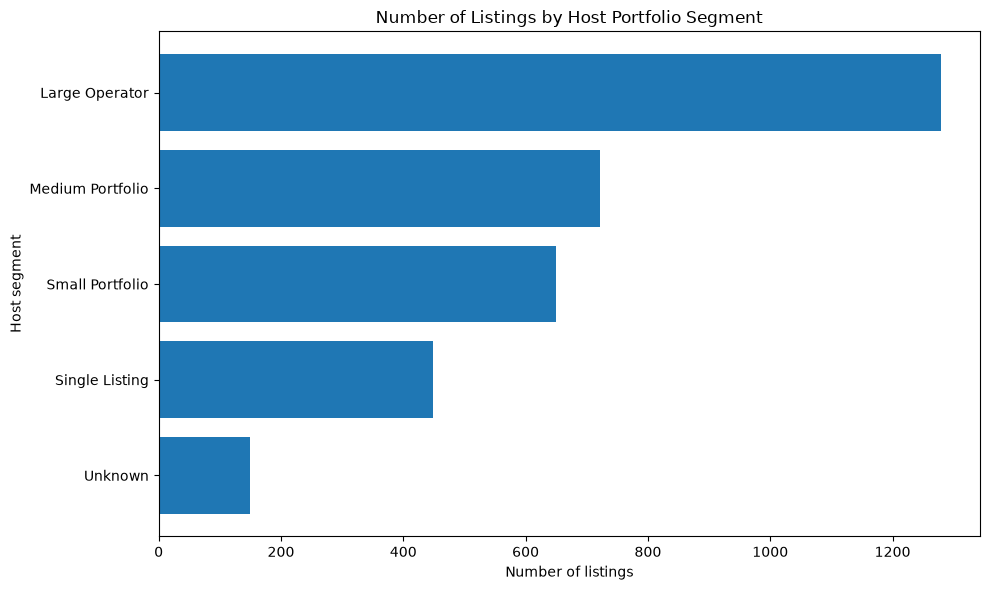

Saved: e:\PROJECTS (selfstudy)\expernetic-airbnb-data-engineering\outputs\charts\eda\04_listings_by_host_segment.png


In [13]:
host_segment_plot = (
    host_segment_summary
    .sort_values(
        "listing_count",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    host_segment_plot[
        "host_segment"
    ],
    host_segment_plot[
        "listing_count"
    ]
)

plt.title(
    "Number of Listings by Host Portfolio Segment"
)

plt.xlabel("Number of listings")
plt.ylabel("Host segment")

save_chart(
    "04_listings_by_host_segment.png"
)

## Business interpretation

These values represent listing counts, not host counts. A large number of
listings controlled by medium and large operators may indicate a more
professionalised market. The top-host concentration measure should be used
to determine how much supply is controlled by a relatively small group of
hosts.

Host market concentration curve

In [15]:
host_listing_counts = (
    listings
    .dropna(
        subset=["host_id"]
    )
    .groupby("host_id")
    .agg(
        listing_count=(
            "id",
            "nunique"
        )
    )
    .sort_values(
        "listing_count",
        ascending=False
    )
    .reset_index()
)

host_listing_counts[
    "host_rank"
] = np.arange(
    1,
    len(host_listing_counts) + 1
)

host_listing_counts[
    "cumulative_listing_count"
] = (
    host_listing_counts[
        "listing_count"
    ].cumsum()
)

host_listing_counts[
    "cumulative_listing_share_percentage"
] = (
    host_listing_counts[
        "cumulative_listing_count"
    ]
    / host_listing_counts[
        "listing_count"
    ].sum()
    * 100
)

host_listing_counts[
    "cumulative_host_share_percentage"
] = (
    host_listing_counts[
        "host_rank"
    ]
    / len(host_listing_counts)
    * 100
)

display(
    host_listing_counts.head(20)
)

save_table(
    host_listing_counts,
    "host_listing_concentration.csv"
)

,host_id,listing_count,host_rank,cumulative_listing_count,cumulative_listing_share_percentage,cumulative_host_share_percentage
0,138649185,215,1,215,6.942202,0.131234
1,238891646,131,2,346,11.172102,0.262467
2,2413412,91,3,437,14.110429,0.393701
3,8948251,73,4,510,16.467549,0.524934
4,109333133,73,5,583,18.824669,0.656168
5,23336011,71,6,654,21.117210,0.787402
6,46685310,71,7,725,23.409751,0.918635
7,10248444,64,8,789,25.476267,1.049869
8,61619807,60,9,849,27.413626,1.181102
9,97878860,59,10,908,29.318696,1.312336


Saved: e:\PROJECTS (selfstudy)\expernetic-airbnb-data-engineering\outputs\tables\eda\host_listing_concentration.csv


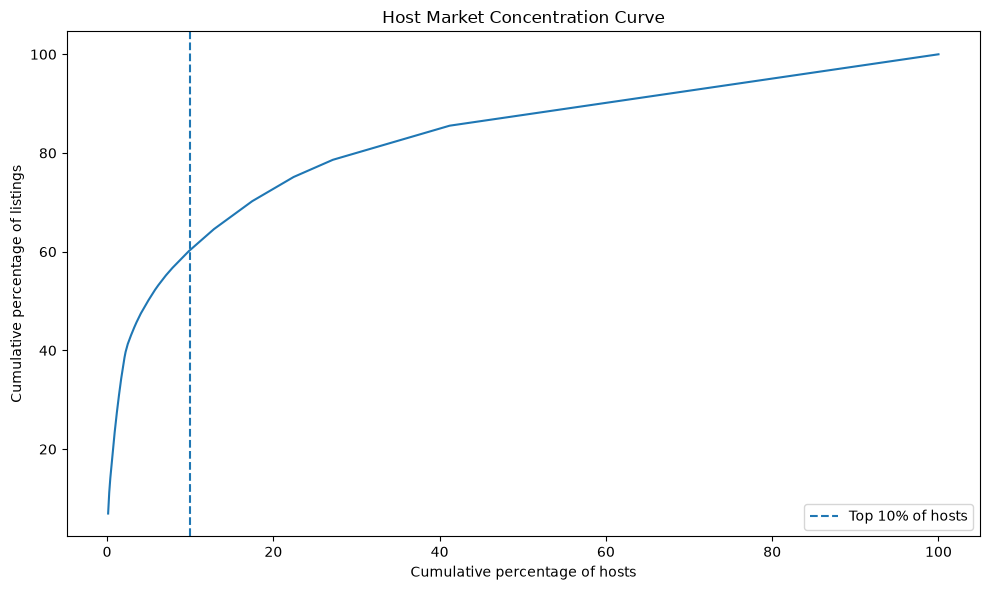

Saved: e:\PROJECTS (selfstudy)\expernetic-airbnb-data-engineering\outputs\charts\eda\05_host_market_concentration.png


In [16]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    host_listing_counts[
        "cumulative_host_share_percentage"
    ],
    host_listing_counts[
        "cumulative_listing_share_percentage"
    ]
)

plt.axvline(
    10,
    linestyle="--",
    label="Top 10% of hosts"
)

plt.title(
    "Host Market Concentration Curve"
)

plt.xlabel(
    "Cumulative percentage of hosts"
)

plt.ylabel(
    "Cumulative percentage of listings"
)

plt.legend()

save_chart(
    "05_host_market_concentration.png"
)

In [17]:
display(host_market_concentration)

,total_hosts,total_host_linked_listings,hosts_in_top_10_percent,listings_controlled_by_top_10_percent,top_10_percent_listing_share
0,762,3097.0,77,1874.0,60.51


Estimated occupancy proxy

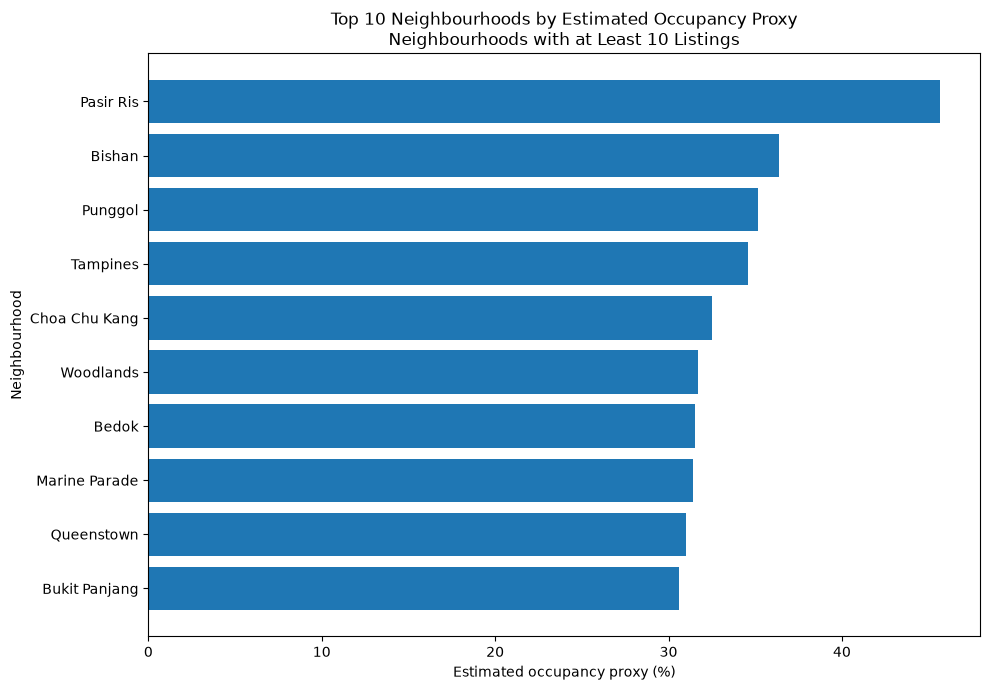

Saved: e:\PROJECTS (selfstudy)\expernetic-airbnb-data-engineering\outputs\charts\eda\06_neighbourhood_occupancy_proxy.png


In [18]:
top_occupancy_neighbourhoods = (
    neighbourhood_analysis
    .dropna(
        subset=[
            "average_occupancy_proxy_percentage"
        ]
    )
    .sort_values(
        "average_occupancy_proxy_percentage",
        ascending=False
    )
    .head(10)
    .sort_values(
        "average_occupancy_proxy_percentage",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_occupancy_neighbourhoods[
        "neighbourhood_cleansed"
    ],
    top_occupancy_neighbourhoods[
        "average_occupancy_proxy_percentage"
    ]
)

plt.title(
    "Top 10 Neighbourhoods by Estimated Occupancy Proxy\n"
    "Neighbourhoods with at Least 10 Listings"
)

plt.xlabel(
    "Estimated occupancy proxy (%)"
)

plt.ylabel("Neighbourhood")

save_chart(
    "06_neighbourhood_occupancy_proxy.png"
)

## Business interpretation

This is an occupancy proxy based on unavailable calendar dates. It does not
represent confirmed bookings. A high value may reflect bookings, host-blocked
dates, maintenance, personal use, or restrictions. The measure is suitable
for directional comparison but not for confirmed revenue estimation.

Reviews and price relationship

In [19]:
review_price_data = (
    listings[
        [
            "detailed_review_count",
            "price"
        ]
    ]
    .copy()
)

review_price_data[
    "detailed_review_count"
] = pd.to_numeric(
    review_price_data[
        "detailed_review_count"
    ],
    errors="coerce"
)

review_price_data["price"] = pd.to_numeric(
    review_price_data["price"],
    errors="coerce"
)

review_price_data = (
    review_price_data
    .dropna()
)

review_limit = review_price_data[
    "detailed_review_count"
].quantile(0.99)

price_limit = review_price_data[
    "price"
].quantile(0.99)

review_price_chart_data = (
    review_price_data[
        (
            review_price_data[
                "detailed_review_count"
            ] <= review_limit
        )
        & (
            review_price_data[
                "price"
            ] <= price_limit
        )
    ]
)

spearman_statistic, spearman_p_value = (
    spearmanr(
        review_price_data[
            "detailed_review_count"
        ],
        review_price_data[
            "price"
        ]
    )
)

review_price_correlation = pd.DataFrame([
    {
        "method": "Spearman correlation",
        "variables": (
            "Detailed review count "
            "and listing price"
        ),
        "correlation": round(
            spearman_statistic,
            4
        ),
        "p_value": spearman_p_value,
        "observations": len(
            review_price_data
        )
    }
])

display(review_price_correlation)

save_table(
    review_price_correlation,
    "review_price_correlation.csv"
)

,method,variables,correlation,p_value,observations
0,Spearman correlation,Detailed review count and listing price,-0.0168,0.378377,2742


Saved: e:\PROJECTS (selfstudy)\expernetic-airbnb-data-engineering\outputs\tables\eda\review_price_correlation.csv


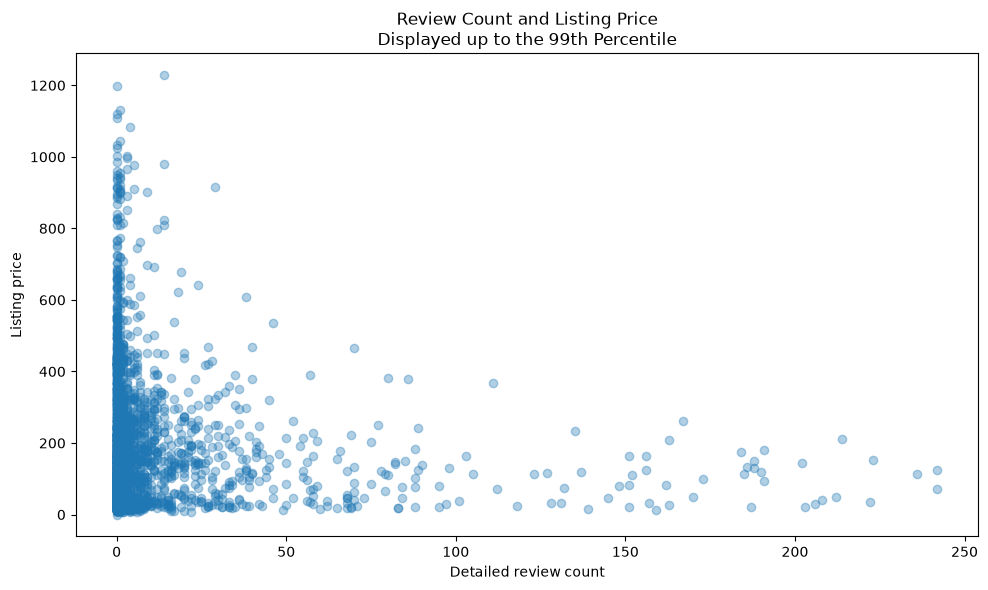

Saved: e:\PROJECTS (selfstudy)\expernetic-airbnb-data-engineering\outputs\charts\eda\07_review_count_vs_price.png


In [20]:
plt.figure(
    figsize=(10, 6)
)

plt.scatter(
    review_price_chart_data[
        "detailed_review_count"
    ],
    review_price_chart_data[
        "price"
    ],
    alpha=0.35
)

plt.title(
    "Review Count and Listing Price\n"
    "Displayed up to the 99th Percentile"
)

plt.xlabel("Detailed review count")
plt.ylabel("Listing price")

save_chart(
    "07_review_count_vs_price.png"
)

## Business interpretation

Review count is an imperfect proxy for historical demand. A correlation does
not show that reviews cause price changes. Listing age, room type,
neighbourhood, and host practices may influence both measures.

Review activity over time

In [21]:
monthly_review_activity[
    "month_start"
] = pd.to_datetime(
    dict(
        year=monthly_review_activity[
            "year_number"
        ].astype(int),
        month=monthly_review_activity[
            "month_number"
        ].astype(int),
        day=1
    )
)

monthly_review_activity = (
    monthly_review_activity
    .sort_values("month_start")
)

display(
    monthly_review_activity.tail(24)
)

,year_number,month_number,month_name,review_count,listings_reviewed,unique_reviewers,average_review_length,month_start
156,2024,7,July,407,159,403,176.89,2024-07-01
157,2024,8,August,446,168,438,188.27,2024-08-01
158,2024,9,September,451,191,437,203.33,2024-09-01
159,2024,10,October,433,152,423,188.56,2024-10-01
160,2024,11,November,476,167,463,167.16,2024-11-01
161,2024,12,December,469,178,462,163.60,2024-12-01
162,2025,1,January,545,183,537,189.77,2025-01-01
163,2025,2,February,544,183,531,185.72,2025-02-01
164,2025,3,March,531,174,513,183.61,2025-03-01
165,2025,4,April,621,225,608,193.43,2025-04-01


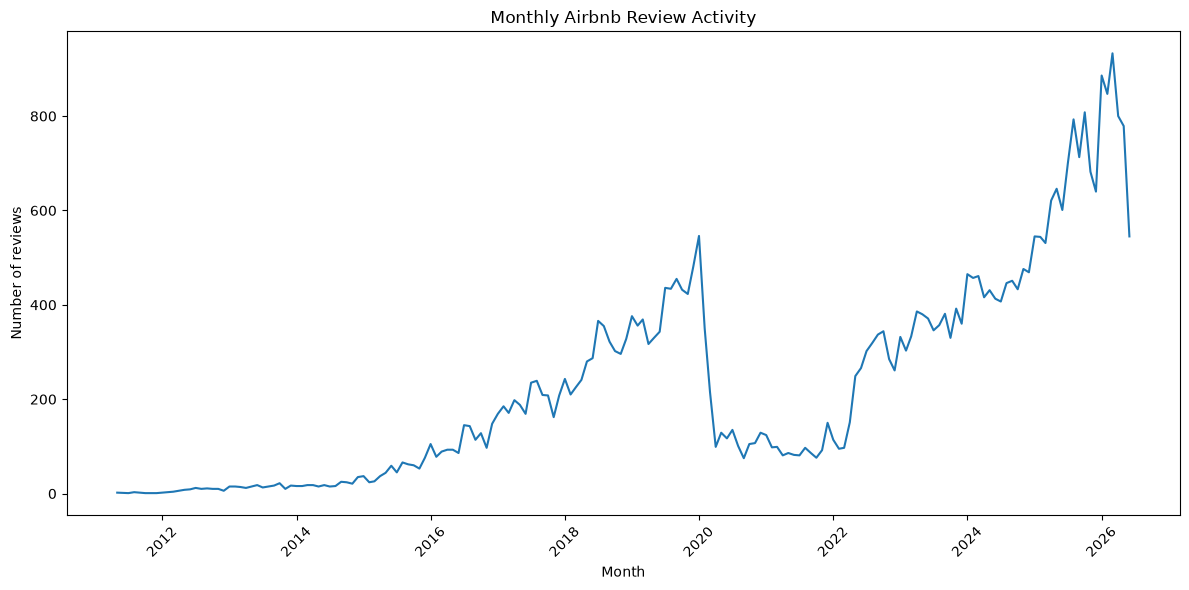

Saved: e:\PROJECTS (selfstudy)\expernetic-airbnb-data-engineering\outputs\charts\eda\08_monthly_review_activity.png


In [22]:
plt.figure(
    figsize=(12, 6)
)

plt.plot(
    monthly_review_activity[
        "month_start"
    ],
    monthly_review_activity[
        "review_count"
    ]
)

plt.title(
    "Monthly Airbnb Review Activity"
)

plt.xlabel("Month")
plt.ylabel("Number of reviews")

plt.xticks(rotation=45)

save_chart(
    "08_monthly_review_activity.png"
)

## Business interpretation

Review volume can provide a broad indication of booking activity over time,
but not every guest leaves a review. Changes may also reflect listing supply,
travel restrictions, platform behaviour, or incomplete coverage.

Monthly availability

In [23]:
monthly_availability[
    "month_start"
] = pd.to_datetime(
    dict(
        year=monthly_availability[
            "year_number"
        ].astype(int),
        month=monthly_availability[
            "month_number"
        ].astype(int),
        day=1
    )
)

monthly_availability = (
    monthly_availability
    .sort_values("month_start")
)

display(monthly_availability)

,year_number,month_number,month_name,calendar_observations,available_days,unavailable_days,availability_rate_percentage,occupancy_proxy_percentage,month_start
0,2026,6,June,2605,398.0,2207.0,15.28,84.72,2026-06-01
1,2026,7,July,98716,63325.0,35391.0,64.15,35.85,2026-07-01
2,2026,8,August,100657,83202.0,17455.0,82.66,17.34,2026-08-01
3,2026,9,September,97410,84166.0,13244.0,86.40,13.60,2026-09-01
4,2026,10,October,100657,81133.0,19524.0,80.60,19.40,2026-10-01
5,2026,11,November,97410,82411.0,14999.0,84.60,15.40,2026-11-01
6,2026,12,December,100657,80527.0,20130.0,80.00,20.00,2026-12-01
7,2027,1,January,100657,80250.0,20407.0,79.73,20.27,2027-01-01
8,2027,2,February,90916,72375.0,18541.0,79.61,20.39,2027-02-01
9,2027,3,March,100657,78702.0,21955.0,78.19,21.81,2027-03-01


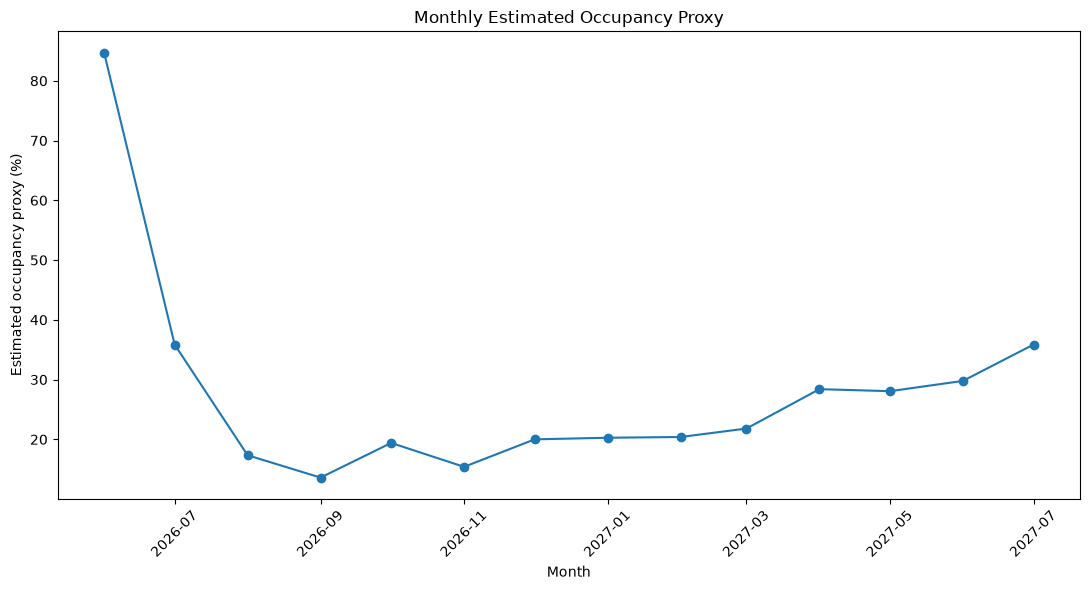

Saved: e:\PROJECTS (selfstudy)\expernetic-airbnb-data-engineering\outputs\charts\eda\09_monthly_occupancy_proxy.png


In [24]:
plt.figure(
    figsize=(11, 6)
)

plt.plot(
    monthly_availability[
        "month_start"
    ],
    monthly_availability[
        "occupancy_proxy_percentage"
    ],
    marker="o"
)

plt.title(
    "Monthly Estimated Occupancy Proxy"
)

plt.xlabel("Month")
plt.ylabel("Estimated occupancy proxy (%)")

plt.xticks(rotation=45)

save_chart(
    "09_monthly_occupancy_proxy.png"
)

## Business interpretation

Changes in the monthly occupancy proxy may indicate seasonal differences in
listing availability. However, the measure cannot distinguish bookings from
host-blocked dates. The calendar dataset also does not contain daily prices,
so seasonal price analysis is outside the available data scope.

Geographic listing density

In [25]:
geographic_data = (
    listings[
        [
            "id",
            "latitude",
            "longitude",
            "room_type",
            "price",
            "neighbourhood_cleansed"
        ]
    ]
    .dropna(
        subset=[
            "latitude",
            "longitude"
        ]
    )
    .copy()
)

geographic_data["latitude"] = pd.to_numeric(
    geographic_data["latitude"],
    errors="coerce"
)

geographic_data["longitude"] = pd.to_numeric(
    geographic_data["longitude"],
    errors="coerce"
)

geographic_data = geographic_data.dropna(
    subset=[
        "latitude",
        "longitude"
    ]
)

print(
    "Listings with usable coordinates:",
    len(geographic_data)
)

Listings with usable coordinates: 3247


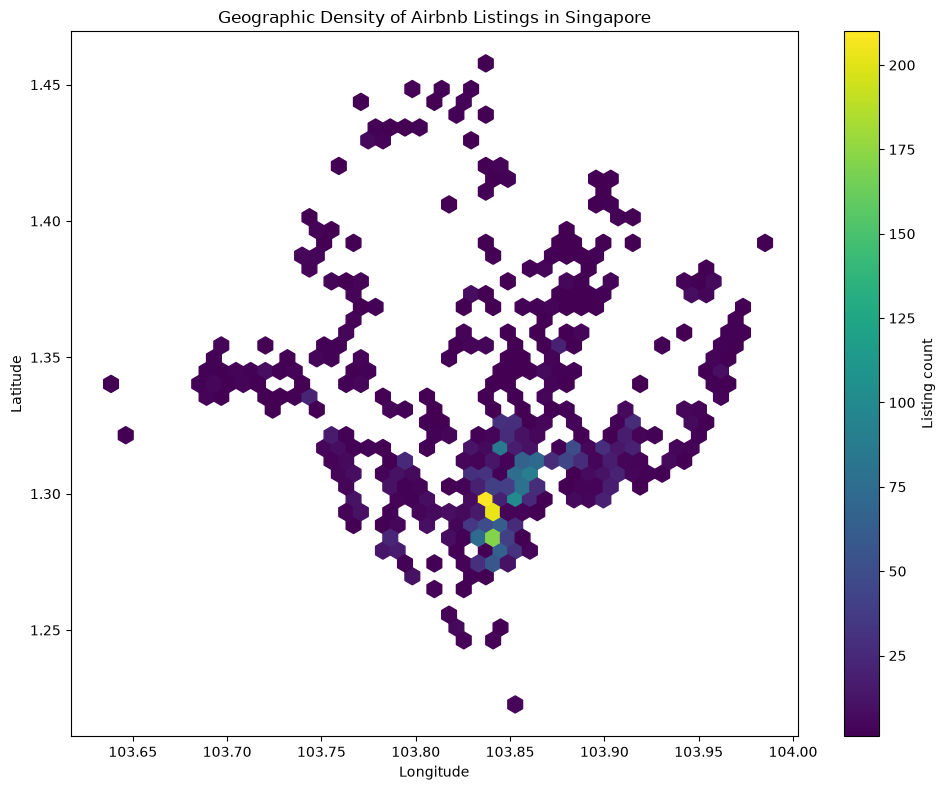

Saved: e:\PROJECTS (selfstudy)\expernetic-airbnb-data-engineering\outputs\charts\eda\10_geographic_listing_density.png


In [26]:
plt.figure(
    figsize=(10, 8)
)

density_plot = plt.hexbin(
    geographic_data["longitude"],
    geographic_data["latitude"],
    gridsize=45,
    mincnt=1
)

plt.colorbar(
    density_plot,
    label="Listing count"
)

plt.title(
    "Geographic Density of Airbnb Listings in Singapore"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

save_chart(
    "10_geographic_listing_density.png"
)

## Business interpretation

The map shows where Airbnb supply is geographically concentrated. Dense
listing clusters may indicate established tourist or commercial areas, but
further analysis is needed before concluding that those locations provide
higher demand or returns.

Create an EDA findings summary

In [27]:
highest_price_room_type = (
    room_type_summary
    .dropna(
        subset=["median_price"]
    )
    .sort_values(
        "median_price",
        ascending=False
    )
    .iloc[0]
)

highest_price_neighbourhood = (
    neighbourhood_analysis
    .dropna(
        subset=["median_price"]
    )
    .sort_values(
        "median_price",
        ascending=False
    )
    .iloc[0]
)

highest_occupancy_neighbourhood = (
    neighbourhood_analysis
    .dropna(
        subset=[
            "average_occupancy_proxy_percentage"
        ]
    )
    .sort_values(
        "average_occupancy_proxy_percentage",
        ascending=False
    )
    .iloc[0]
)

review_coverage_percentage = round(
    (
        listings[
            "detailed_review_count"
        ] > 0
    ).mean() * 100,
    2
)

eda_findings_summary = pd.DataFrame([
    {
        "finding": "Median listing price",
        "value": round(
            price_values.median(),
            2
        )
    },
    {
        "finding": "Highest median-price room type",
        "value": (
            f"{highest_price_room_type['room_type']} "
            f"({highest_price_room_type['median_price']:.2f})"
        )
    },
    {
        "finding": (
            "Highest median-price neighbourhood "
            "with at least 10 listings"
        ),
        "value": (
            f"{highest_price_neighbourhood['neighbourhood_cleansed']} "
            f"({highest_price_neighbourhood['median_price']:.2f})"
        )
    },
    {
        "finding": (
            "Highest occupancy-proxy neighbourhood "
            "with at least 10 listings"
        ),
        "value": (
            f"{highest_occupancy_neighbourhood['neighbourhood_cleansed']} "
            f"({highest_occupancy_neighbourhood['average_occupancy_proxy_percentage']:.2f}%)"
        )
    },
    {
        "finding": "Listings with detailed reviews",
        "value": f"{review_coverage_percentage}%"
    },
    {
        "finding": (
            "Review count and price "
            "Spearman correlation"
        ),
        "value": round(
            spearman_statistic,
            4
        )
    }
])

display(eda_findings_summary)

save_table(
    eda_findings_summary,
    "eda_findings_summary.csv"
)

,finding,value
0,Median listing price,130.05
1,Highest median-price room type,Entire home/apt (214.11)
2,Highest median-price neighbourhood with at lea...,Orchard (422.00)
3,Highest occupancy-proxy neighbourhood with at ...,Pasir Ris (45.68%)
4,Listings with detailed reviews,56.64%
5,Review count and price Spearman correlation,-0.0168


Saved: e:\PROJECTS (selfstudy)\expernetic-airbnb-data-engineering\outputs\tables\eda\eda_findings_summary.csv
